# Actividad de Laboratorio 2
El objetivo de esta Actividad de Laboratorio es implementar y analizar algoritmos simples de clasificación 
en 8 tipos de organismos microscópicos (amebas, euglenas, hidras, paramecios, bacterias (varas/esferas/espiral) 
y  levadura).  Para  ello,  debe  descargar  los  archivos  cell_gal.zip  y  cell_test.zip  que  contienen  las  imágenes 
necesarias para construir los conjuntos de galería y prueba respectivamente.

## P1
Implemente el algoritmo de análisis de textura LBP usando una matriz de 3x3. Aplique LBP a todas las 
imágenes de organismos microscópicos y guarde los resultados. ¿Qué características tienen las imágenes 
procesadas con LBP?   

Respuesta:
Las imágenes LBP resaltan patrones locales de textura, mostrando bordes y detalles finos. Son útiles para distinguir estructuras microscópicas por sus texturas.



Procesamiento LBP terminado. Imágenes guardadas en lbp_results.


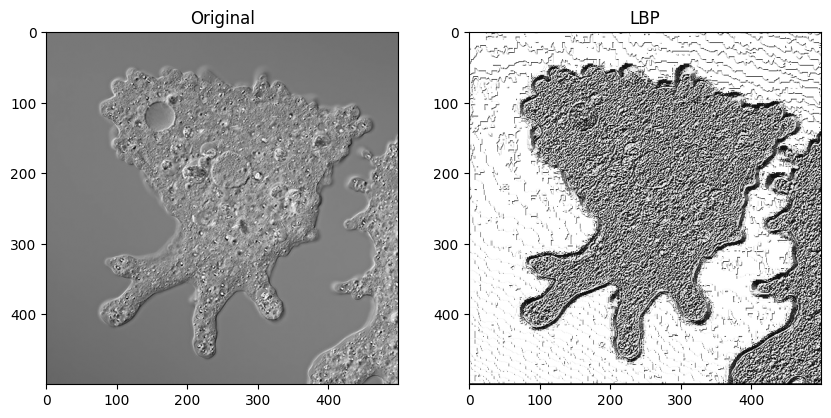

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def lbp_3x3(img_gray):
    # Asume que img_gray es una imagen en escala de grises (numpy array)
    lbp_img = np.zeros_like(img_gray)
    for i in range(1, img_gray.shape[0] - 1):
        for j in range(1, img_gray.shape[1] - 1):
            center = img_gray[i, j]
            binary_str = ''
            # Recorrer vecinos en 3x3
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if dx == 0 and dy == 0:
                        continue
                    neighbor = img_gray[i + dx, j + dy]
                    binary_str += '1' if neighbor >= center else '0'
            lbp_img[i, j] = int(binary_str, 2)
    return lbp_img


input_folder = r'C:\Users\tomas\Desktop\EL5206_Experiencia_2\02\cell_gal'
output_folder = r'C:\Users\tomas\Desktop\EL5206_Experiencia_2\lbp_results'
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith('.jpg'):
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        lbp_img = lbp_3x3(img)
        out_path = os.path.join(output_folder, f'LBP_{filename}')
        cv2.imwrite(out_path, lbp_img)

print("Procesamiento LBP terminado. Imágenes guardadas en lbp_results.")



# Ej:
path = 'C:\\Users\\tomas\\Desktop\\EL5206_Experiencia_2\\02\\cell_gal\\I1_gal.jpg'
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
lbp_result = lbp_3x3(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('LBP')
plt.imshow(lbp_result, cmap='gray')
plt.show()

# P2
Desarrolle  un  algoritmo  para  extraer  un  vector  de  características  para  cada  imagen.  Para  ello  divida  la imagen de entrada en 25 regiones de 100x100 pixeles (ancho x alto) y a cada una de ellas calcúlele un 
histograma  cuantizado  en  87  puntos.  Concatene  los  25  histogramas  conseguidos  en  un  vector  de 
dimensiones 1x2175 que será el elemento de salida al método de extracción de características. Adjunte 
este algoritmo a su informe

In [ ]:
#Para ese caso lo que haremos es separar la imagen en 25 regiones de 100x100 pixeles y a cada una de ellas le calcularemos un histograma cuantizado en 87 puntos. 
#Luego concatenamos los 25 histogramas en un vector de tamaño 1x2175.
#Esto entrega las caracteristivas de las regiones las cuales luego concatenamos para obtener el vector final.

def extraer_vector_caracteristicas(img_gray):
    # Asume que img_gray tiene al menos 500x500 píxeles
    regiones = []
    for i in range(5):
        for j in range(5):
            x_ini, x_fin = j*100, (j+1)*100
            y_ini, y_fin = i*100, (i+1)*100
            region = img_gray[y_ini:y_fin, x_ini:x_fin]
            hist, _ = np.histogram(region, bins=87, range=(0,256))
            regiones.append(hist)
    vector = np.concatenate(regiones)
    return vector  # Vector de tamaño 1x2175

# Ejemplo de uso:
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
vector = extraer_vector_caracteristicas(img)

# P3 
Implemente la siguiente medida de distancia entre dos vectores de largo n: 
$$
d(x,y) = \sum^n_{i=1} |x_i - y_i|
$$


In [15]:
def medida_distancia(x, y):
    """
    Calcula la distancia Manhattan (L1) entre dos vectores x e y de igual largo.
    """
    return np.sum(np.abs(x - y))   

# P4
Construya  una  base  de  datos  usando  las  imágenes  del  archivo  cell_gal.zip.  Esto  incluye  procesar  las imágenes usando LBP, la posterior extracción y almacenamiento del vector de características para cada 
una de ellas.

In [14]:
#ocuparemos pandass para manejar la base de datos
import pandas as pd

input_folder = r'C:\Users\tomas\Desktop\EL5206_Experiencia_2\02\cell_gal'
db = []

for filename in os.listdir(input_folder):
    if filename.lower().endswith('.jpg'):
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        lbp_img = lbp_3x3(img)
        vector = extraer_vector_caracteristicas(lbp_img)
        db.append({'filename': filename, 'features': vector})

# Guardar la base de datos en un archivo CSV
df = pd.DataFrame([{'filename': d['filename'], **{f'f{i}': d['features'][i] for i in range(len(d['features']))}} for d in db])
df.to_csv(r'C:\Users\tomas\Desktop\EL5206_Experiencia_2\base_datos_lbp.csv', index=False)

print("Base de datos creada y guardada como base_datos_lbp.csv")


Base de datos creada y guardada como base_datos_lbp.csv
